## Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

**Due: Sunday, October 4, 2026, at 11:59 PM ET**

There is a grace period until **2:00 AM ET**. After that, late submissions are penalized **10% for each 24-hour period**. After **5 days**, the score is 0.

In this assignment, you will use a modern pretrained CNN, **MobileNetV2**, to classify the **Intel Image Dataset**, which contains 6 scene classes.

You will begin by using MobileNetV2 as a **frozen feature extractor**, training only a new classification head. You will then explore progressively more flexible transfer-learning strategies by making all or part of the pretrained backbone trainable.

To make experimentation practical, the notebook provides a `DATA_FRACTION` setting. During development, you may use a smaller fraction of the dataset to test ideas and compare configurations more quickly. Before recording your final results, set:

```python
DATA_FRACTION = 1.0
```

and rerun the complete notebook using the full dataset.

Because MobileNetV2 was pretrained on ImageNet, the images are processed using `mobilenet_v2.preprocess_input`, which scales the input pixels to the range expected by the pretrained network.

The goal is to understand **why transfer learning works**, how to design a useful **classification head**, and how choices such as **learning rate**, **learning-rate control with `ReduceLROnPlateau`**, **regularization**, and **which pretrained layers are allowed to change** affect model performance.

### Learning Objectives

By the end of this homework, you should be able to:

* Use a pretrained CNN as a **frozen feature extractor**.
* Design and compare different **classification heads** on top of a pretrained backbone.
* Experiment efficiently using a reduced dataset before running final models on the full dataset.
* Understand the difference between a **frozen backbone** and making some or all pretrained layers trainable.
* Use practical training controls including:

  * fixed **learning rates**,
  * `ReduceLROnPlateau`,
  * `EarlyStopping`,
  * **Dropout** and **L2 regularization**,
  * and **Batch Normalization** in classification heads.
* Compare strategies that make:

  * the **entire backbone** trainable,
  * only the **last N layers** trainable,
  * or only the **top K MobileNetV2 blocks** trainable.

### Baseline Model

The starting backbone is:

```python
MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

With `pooling="avg"`, MobileNetV2 already applies **Global Average Pooling** and outputs a **1280-dimensional feature vector** for each image.

The baseline classification head consists of a single:

```python
Dense(num_classes, activation="softmax")
```

layer for the 6 Intel classes.

**Do not add another pooling layer when `pooling="avg"` is used.**

### The Five Problems

1. **Problem 1 — Frozen Backbone:**
   Keep MobileNetV2 frozen and redesign only the **classification head**. Try at least three head designs and experiment with training hyperparameters.

2. **Problem 2 — Fully Trainable Backbone:**
   Use one of your best head architectures from Problem 1, make the **entire MobileNetV2 backbone trainable**, and experiment with appropriately small learning rates and other training choices.

3. **Problem 3 — Unfreeze the Last N Layers:**
   Keep most of MobileNetV2 frozen while allowing only the **last N layers** to be updated.

4. **Problem 4 — Unfreeze the Top K Blocks:**
   Instead of selecting individual layers, make only the **top K MobileNetV2 blocks or stages** trainable and compare the results.

5. **Problem 5 -- Final Reflection**

Use your **HW4 CNN results as a reference point**. Transfer learning may or may not outperform every model you developed in HW4; the important goal is to understand how the different transfer-learning strategies affect training behavior and model performance.



## 1. Setup and Data Loading


In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 1

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

# print("class_names:", class_names)
# print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

# show_counts_from_labels("train", y_train, class_names)
# show_counts_from_labels("val",   y_val,   class_names)
# show_counts_from_labels("test",  test_labels, class_names)


In [7]:
# # Show 25 sample images

# plt.figure(figsize=(12, 12))

# images, labels = next(iter(train_ds))

# for i in range(25):
#     ax = plt.subplot(5, 5, i + 1)

#     # Convert MobileNetV2 [-1, 1] values back to [0, 1] for display
#     img = (images[i].numpy() + 1.0) / 2.0

#     plt.imshow(img)
#     plt.title(class_names[int(labels[i])], fontsize=9)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


### Learning Rate Schedulers

In [8]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight CNN pretrained on the ImageNet dataset. We will use it as a source of high-quality visual features rather than training a convolutional network from scratch.

See the **Appendix** for additional information about `MobileNetV2`.

The baseline model defined below uses `MobileNetV2` as a frozen **feature extractor**. With `include_top=False` and built-in **Global Average Pooling**, the backbone produces a 1280-dimensional feature vector for each image.

The images have already been processed using `mobilenet_v2.preprocess_input`, which scales the pixel values to the range expected by the pretrained MobileNetV2 weights.

> **NOTE:** The standard MobileNetV2 ImageNet weights are associated with 224×224 images. We use 150×150 images to reduce training time. This is valid because, with `include_top=False`, the convolutional backbone can operate on different input image sizes.
>
> Keras may therefore issue a warning such as:
>
> `UserWarning: input_shape is undefined or non-square, ...`
>
> You may safely ignore this warning for this assignment.


In [9]:
# ALWAYS construct a new instance to avoid sharing layers across models.

def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
        pooling="avg",
    )
    base.trainable = trainable
    return base


base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/tmp/ipykernel_27223/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [10]:
# Ha, this is very long!

# base.summary()

/tmp/ipykernel_27223/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500


/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.8604 - loss: 0.3846 - val_accuracy: 0.8941 - val_loss: 0.3010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9102 - loss: 0.2499 - val_accuracy: 0.8941 - val_loss: 0.2938
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9226 - loss: 0.2138 - val_accuracy: 0.9019 - val_loss: 0.2765
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9252 - loss: 0.2031 - val_accuracy: 0.8969 - val_loss: 0.2862
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9337 - loss: 0.1792 - val_accuracy: 0.8941 - val_loss: 0.2979
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9400 - loss: 0.1644 - val_accuracy: 0.8951 - val_loss: 0.2951
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9416 - loss: 0.1541 - val_accuracy: 0.8898 - val_loss: 0.3194
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9468 - loss: 0.1512 - val_accurac

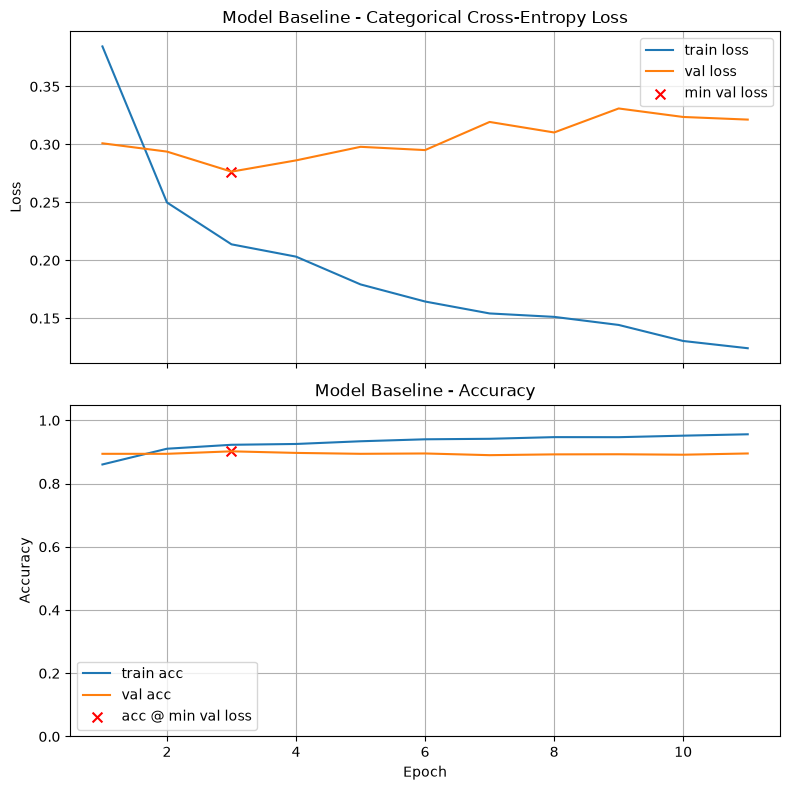

Final Training Loss:            0.1241
Final Training Accuracy:        0.9558
Final Validation Loss:          0.3214
Final Validation Accuracy:      0.8951
Minimum Validation Loss:        0.2765 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9019

Test Loss: 0.2570
Test Accuracy: 0.9023

Validation-Test Gap (accuracy): 0.000408

Execution Time: 00:01:35


In [11]:
# Construct a fresh frozen MobileNetV2 backbone

base_model = make_base_model_pooled()

model_baseline = models.Sequential([
    base_model,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_baseline, title="Model Baseline")

### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and try to improve accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_model_pooled(
    trainable=False
)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D feature vector** for each image.

Do **not** unfreeze any backbone layers, and do **not** add another pooling layer.

### To Do

1. **Ask an AI helper** (e.g., ChatGPT):

   *“What are some more complex classification heads that could improve this model on the Intel Image Classification Dataset, without unfreezing the MobileNetV2 backbone?”*

2. **Implement at least three different head designs.** These may be AI-suggested or inspired by techniques used in HW4.

3. **Experiment with hyperparameters** for the different designs, such as:

   * learning rate
   * `EarlyStopping` settings
   * Dropout and/or L2 regularization
   * `ReduceLROnPlateau` on or off

4. **Train and compare** the three head designs using a reduced value of `DATA_FRACTION`.

   Use these runs to compare architectures and training behavior and to narrow down a reasonable final configuration.

5. **Select one configuration**, set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this full-data run when answering the graded questions.

6. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the backbone output has shape **(None, 1280)**, so **do not add `GlobalAveragePooling2D()`** to the head.
* `BatchNormalization` may be used within the classification head.
* Keep the entire MobileNetV2 backbone frozen for all experiments in this problem.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.



In [13]:
allrun = time.time()

/tmp/ipykernel_27223/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p1- small head - base LR 1e-3



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


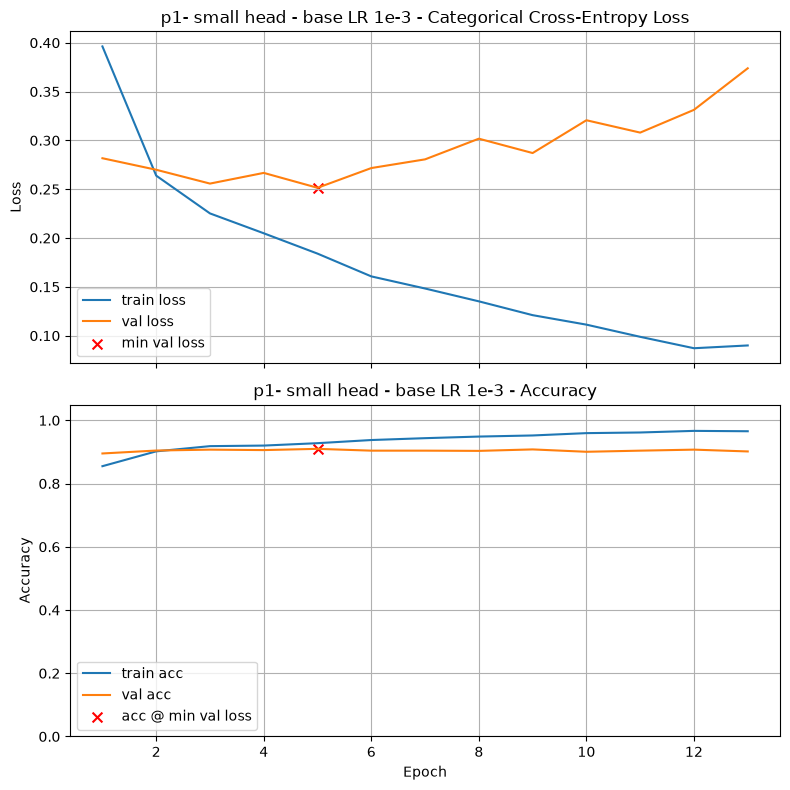

Final Training Loss:            0.0900
Final Training Accuracy:        0.9654
Final Validation Loss:          0.3739
Final Validation Accuracy:      0.9016
Minimum Validation Loss:        0.2514 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9098

Test Loss: 0.2364
Test Accuracy: 0.9070

Validation-Test Gap (accuracy): 0.002772

Execution Time: 00:01:39

p1- larger head - base LR 1e-3



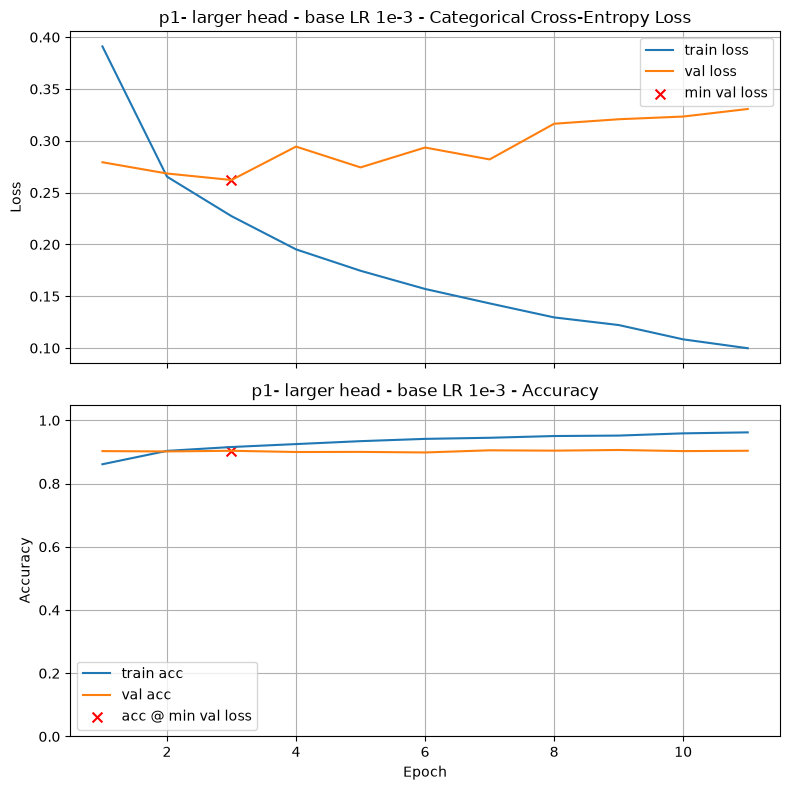

Final Training Loss:            0.0999
Final Training Accuracy:        0.9619
Final Validation Loss:          0.3307
Final Validation Accuracy:      0.9037
Minimum Validation Loss:        0.2622 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9037

Test Loss: 0.2264
Test Accuracy: 0.9097

Validation-Test Gap (accuracy): 0.005958

Execution Time: 00:01:21

p1- small do head - base LR 1e-3



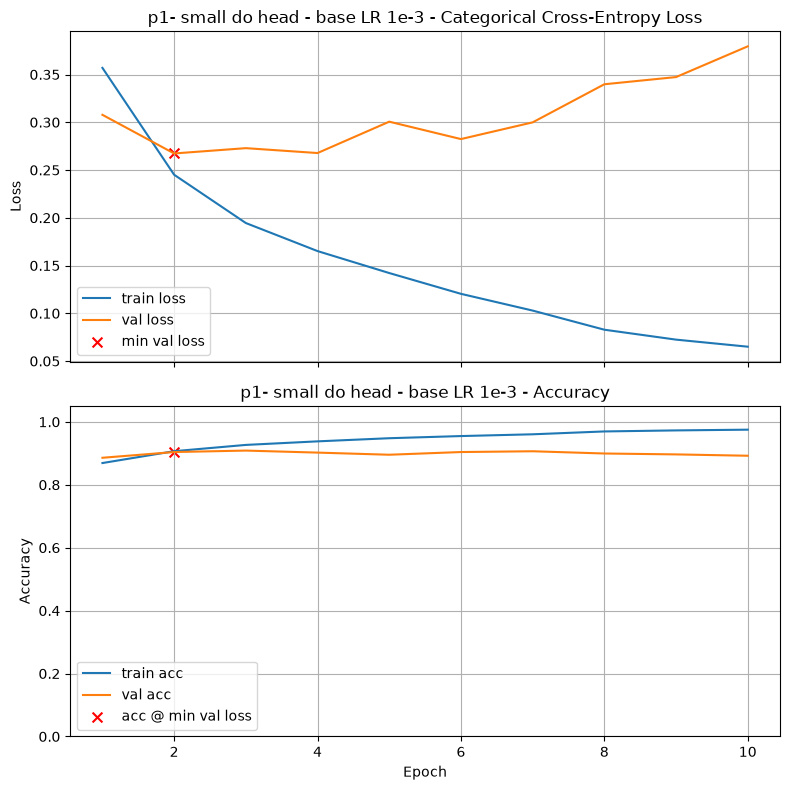

Final Training Loss:            0.0651
Final Training Accuracy:        0.9752
Final Validation Loss:          0.3795
Final Validation Accuracy:      0.8923
Minimum Validation Loss:        0.2673 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9041

Test Loss: 0.2531
Test Accuracy: 0.9033

Validation-Test Gap (accuracy): 0.000732

Execution Time: 00:01:17

p1- larger head - lr 1e-4, reduce LR, l2 reg


Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


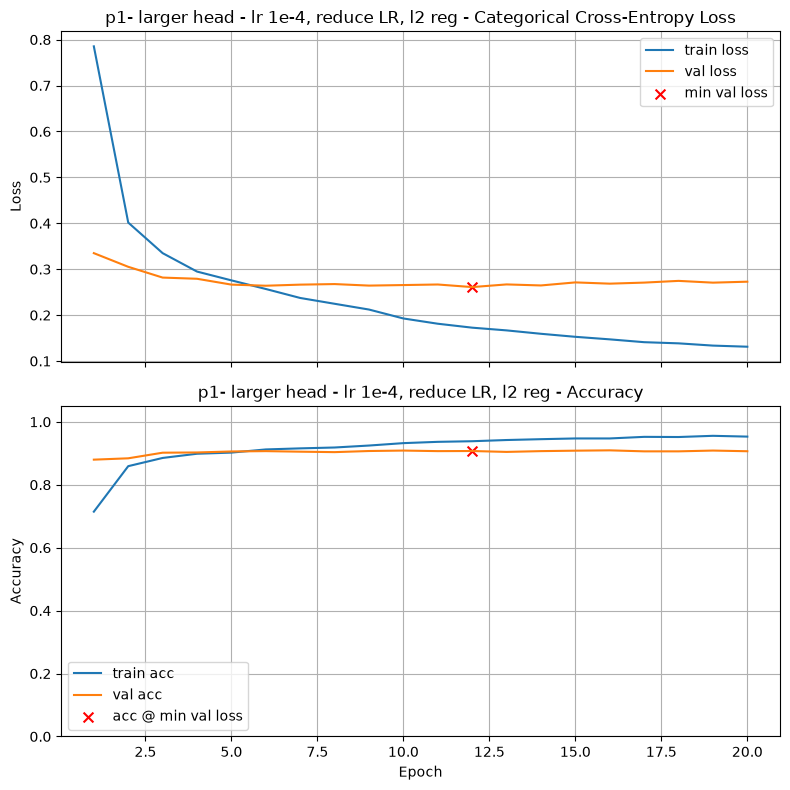

Final Training Loss:            0.1312
Final Training Accuracy:        0.9531
Final Validation Loss:          0.2728
Final Validation Accuracy:      0.9066
Minimum Validation Loss:        0.2611 (Epoch 12)
Validation Accuracy @ Min Loss: 0.9073

Test Loss: 0.2402
Test Accuracy: 0.9133

Validation-Test Gap (accuracy): 0.006058

Execution Time: 00:02:22


In [14]:
# Your code here; add additional code cells as needed

def p1_buildmodel(
        backbone,
        head_config, 
        l2_reg = None, 
):
    model = models.Sequential([backbone])

    l2reg = tf.keras.regularizers.L2(l2_reg) if l2_reg else None

    for layer_cfg in head_config:
        if layer_cfg["type"] == "dense":
            model.add(tf.keras.layers.Dense(
                units=layer_cfg["units"],
                activation="relu",
                kernel_regularizer=l2reg
            ))

        #     model.add(tf.keras.layers.Dense(
        #     units=layer_cfg["units"],
        #     activation=None,  # ReLU happens after normalization
        #     use_bias=False,
        #     kernel_regularizer=tf.keras.regularizers.L2(l2_reg)
        # ))

        #     model.add(tf.keras.layers.BatchNormalization())
        #     model.add(tf.keras.layers.Activation("relu"))

        elif layer_cfg["type"] == "dropout":
            model.add(tf.keras.layers.Dropout(
                rate=layer_cfg["rate"]
            ))

        else:
            raise ValueError(f"Unknown layer type: {layer_cfg['type']}")

    model.add(tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    ))

    return model

p1_head_configs = {
    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    "larger": [
        {"type": "dense",   "units": 256},
        {"type": "dropout", "rate": 0.3},
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    "smaller_do": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.1},
    ],
}

p1_experiments = {
    "p1- small head - base LR 1e-3":    dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),

    "p1- larger head - base LR 1e-3":   dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),    

    "p1- small do head - base LR 1e-3":    dict(
                                        head="smaller_do",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),                                                           


    "p1- larger head - lr 1e-4, reduce LR, l2 reg":   dict(
                                        head="larger", 
                                        lr=1e-4, 
                                        earlystop = True,
                                        reduceLR = [reduce_lr],
                                        l2_reg=1e-5),
}

for title, config in p1_experiments.items():
    tf.keras.backend.clear_session()

    p1_model = p1_buildmodel(
        backbone=make_base_model_pooled(trainable=False),
        head_config=p1_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
    )

    train_and_test(
        p1_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = False
    )


    del p1_model



    


# Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that suggest about the role of head design and hyperparameters when the backbone is frozen?

**Instructions:**

- Write a single paragraph (3–5 sentences).
- Identify the head architecture and experiment that performed best.
- Briefly compare it with the other experiments, referring to specific design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate, ReduceLROnPlateau).
- Explain which of these differences you think were most important, based on your observed training and validation results.
- Conclude with what your experiments suggest about designing classification heads when the backbone is frozen.


**Your paragraph here (5pts):**

> answer:
From the experiments, the validation accuracies are generally similar (within 2 decimal points). 
Having multiple head layers vs single, may not change that much accuracy. However, changing the hyperparameters sometimes did not improve the accuracy at all. While the backbone is frozen, seesm like the head design is the best next place to increase accuracy greatly.

**Validation Accuracy here (15 pts):**

In [15]:
results

{'Model Baseline': (0.901925802230835, 3),
 'p1- small head - base LR 1e-3': (0.909771740436554, 5),
 'p1- larger head - base LR 1e-3': (0.9037089943885803, 3),
 'p1- small do head - base LR 1e-3': (0.9040656089782715, 2),
 'p1- larger head - lr 1e-4, reduce LR, l2 reg': (0.9072753190994263, 12)}

In [39]:
# Set a1 to the validation accuracy found by your best model for this problem. 

a1 = 0.909771740            # Replace 0.0 with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem         

print(f'a1 = {a1:.4f}') 


a1 = 0.9098


## Problem Two — Training MobileNetV2 with the Backbone Unfrozen

**Goal.** Use the architecture of one of your best heads from Problem 1, but now make the MobileNetV2 backbone trainable so that the entire network can adapt to the Intel Image dataset.

**Setup.** Build a new MobileNetV2 backbone with `trainable=True`. It already applies Global Average Pooling and outputs a 1280-D vector, so do not add another pooling layer.

```python
base = make_base_model_pooled(
    trainable=True
)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do

1. **Design at least three experiments** with the MobileNetV2 backbone fully unfrozen. Use the architecture of one of your best heads from Problem 1 and vary one or more of the following:

   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration**, set `DATA_FRACTION = 1.0`, rerun the notebook to train on the full dataset, and use this run when answering the graded questions.

### Notes

* Training a pretrained backbone generally requires a **much smaller learning rate** than training only a new classification head. Values such as \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points.
* Small changes in relative performance between experiments using a reduced dataset and the full dataset are expected.
* Each experiment should construct a **new model** so that experiments do not inherit weights from previous runs.



/tmp/ipykernel_27223/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p2- small head - base LR 1e-3



E0000 00:00:1791051829.387616   27285 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1791051870.416438   27286 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


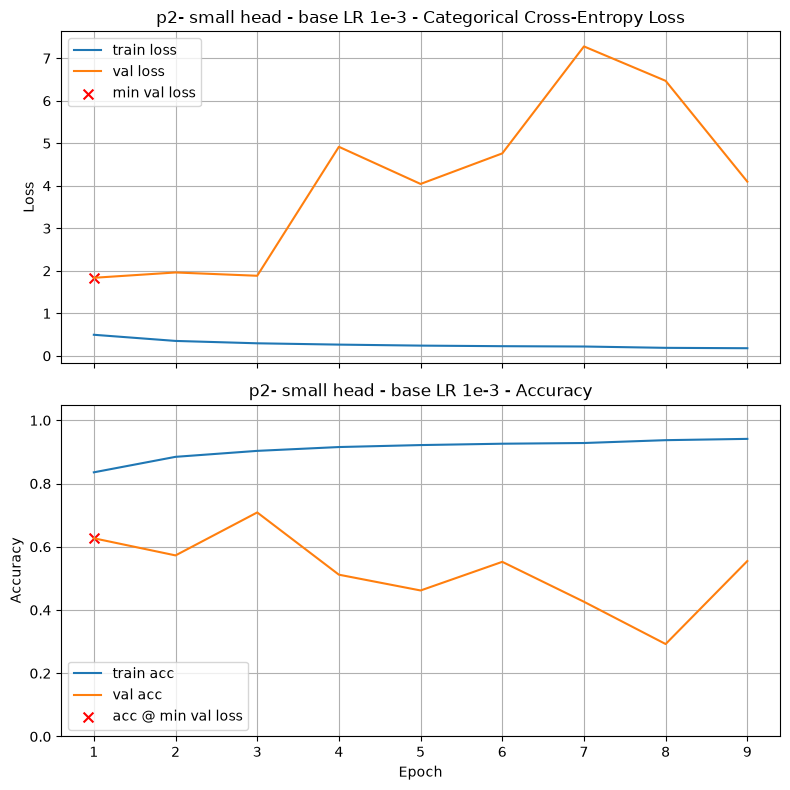

Final Training Loss:            0.1794
Final Training Accuracy:        0.9413
Final Validation Loss:          4.0976
Final Validation Accuracy:      0.5549
Minimum Validation Loss:        1.8360 (Epoch 1)
Validation Accuracy @ Min Loss: 0.6270

Test Loss: 1.9167
Test Accuracy: 0.6263

Validation-Test Gap (accuracy): 0.000628

Execution Time: 00:03:29

p2- larger head - base LR 1e-3



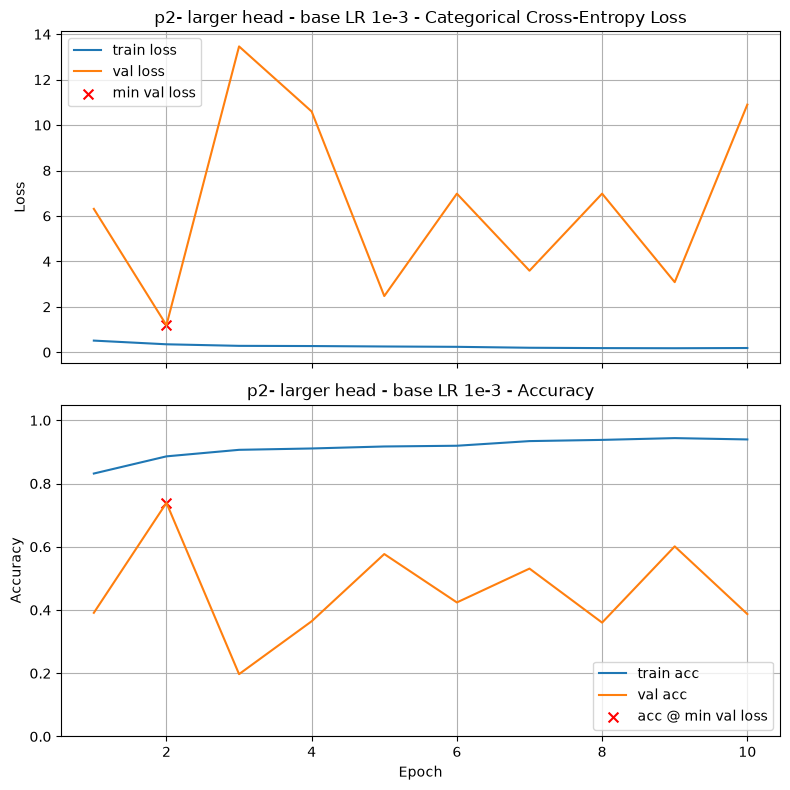

Final Training Loss:            0.1856
Final Training Accuracy:        0.9395
Final Validation Loss:          10.8999
Final Validation Accuracy:      0.3873
Minimum Validation Loss:        1.1901 (Epoch 2)
Validation Accuracy @ Min Loss: 0.7389

Test Loss: 1.2142
Test Accuracy: 0.7330

Validation-Test Gap (accuracy): 0.005944

Execution Time: 00:03:31

p2- small head - LR 1e-5



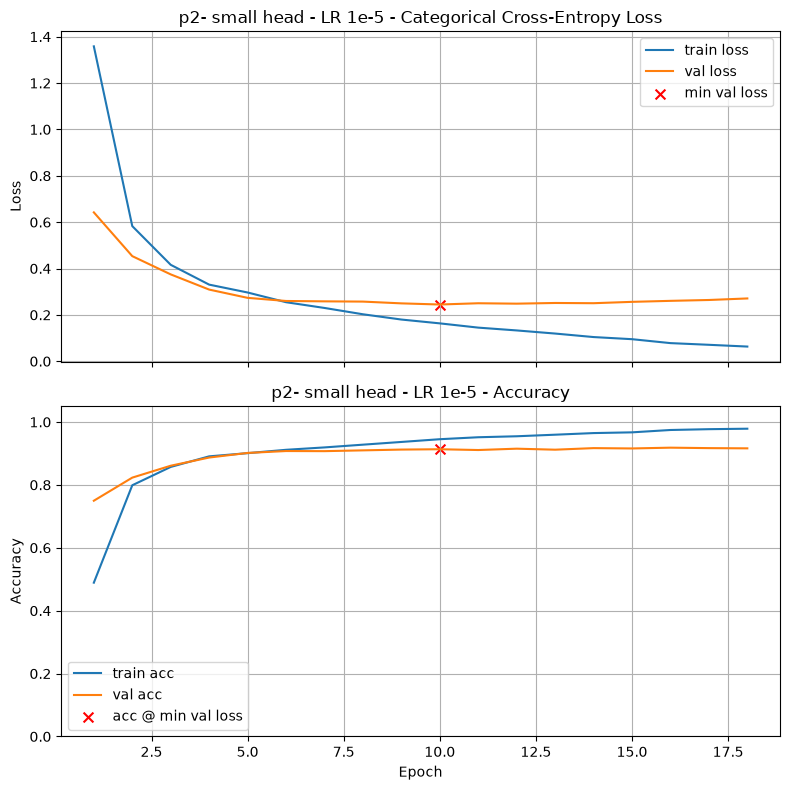

Final Training Loss:            0.0634
Final Training Accuracy:        0.9786
Final Validation Loss:          0.2710
Final Validation Accuracy:      0.9162
Minimum Validation Loss:        0.2448 (Epoch 10)
Validation Accuracy @ Min Loss: 0.9133

Test Loss: 0.2254
Test Accuracy: 0.9213

Validation-Test Gap (accuracy): 0.007995

Execution Time: 00:05:27

p2- small head - lr 1e-5, reduce LR, l2 reg


Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.


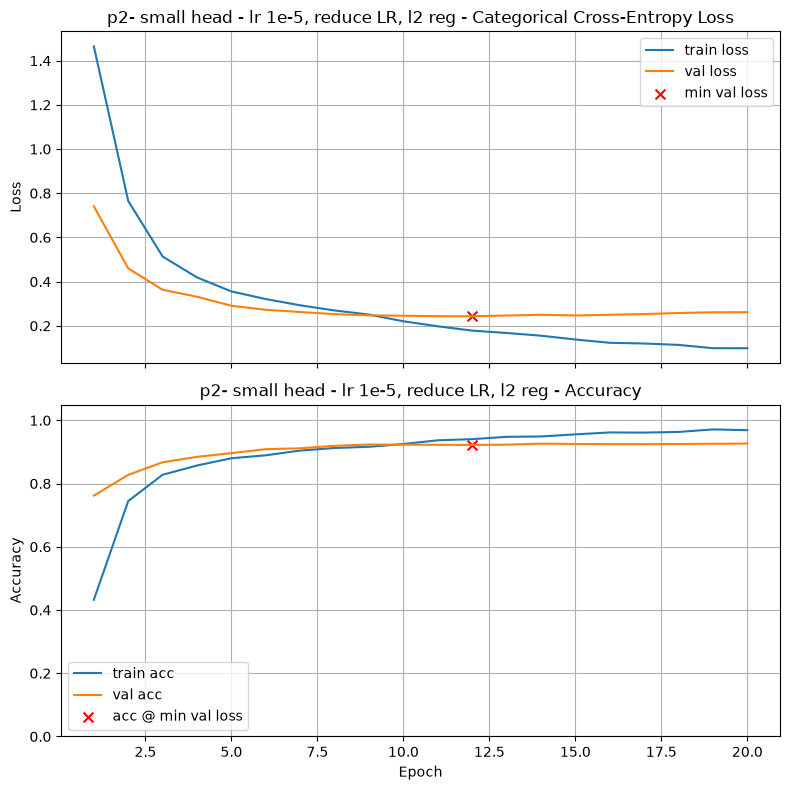

Final Training Loss:            0.0988
Final Training Accuracy:        0.9688
Final Validation Loss:          0.2619
Final Validation Accuracy:      0.9265
Minimum Validation Loss:        0.2434 (Epoch 12)
Validation Accuracy @ Min Loss: 0.9223

Test Loss: 0.2273
Test Accuracy: 0.9237

Validation-Test Gap (accuracy): 0.001413

Execution Time: 00:05:54


In [18]:
# Your code here; add as many cells as you need
p2_head_configs = {
    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    "larger": [
        {"type": "dense",   "units": 256},
        {"type": "dropout", "rate": 0.3},
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
    # "smaller_do": [
    #     {"type": "dense",   "units": 128},
    #     {"type": "dropout", "rate": 0.1},
    # ],
}

p2_experiments = {
    "p2- small head - base LR 1e-3":    dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),

    "p2- larger head - base LR 1e-3":   dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),    

    "p2- small head - LR 1e-5":         dict(
                                        head="small",  
                                        lr=1e-5, 
                                        earlystop = True,
                                        reduceLR = False,
                                        l2_reg=None),                                                           

    "p2- small head - lr 1e-5, reduce LR, l2 reg":   dict(
                                        head="larger", 
                                        lr=1e-5, 
                                        earlystop = True,
                                        reduceLR = [reduce_lr],
                                        l2_reg=1e-5),
}




for title, config in p2_experiments.items():
    tf.keras.backend.clear_session()

    p2_model = p1_buildmodel(
        backbone=make_base_model_pooled(trainable= True),
        head_config=p2_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
    )

    train_and_test(
        p2_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = False
    )

    del p2_model



    

In [19]:
results

{'Model Baseline': (0.901925802230835, 3),
 'p1- small head - base LR 1e-3': (0.909771740436554, 5),
 'p1- larger head - base LR 1e-3': (0.9037089943885803, 3),
 'p1- small do head - base LR 1e-3': (0.9040656089782715, 2),
 'p1- larger head - lr 1e-4, reduce LR, l2 reg': (0.9072753190994263, 12),
 'p2- small head - base LR 1e-3': (0.6269614696502686, 1),
 'p2- larger head - base LR 1e-3': (0.7389443516731262, 2),
 'p2- small head - LR 1e-5': (0.9133380651473999, 10),
 'p2- small head - lr 1e-5, reduce LR, l2 reg': (0.9222539067268372, 12)}

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which fully unfrozen configuration worked best for you, and what does that suggest about the role of head design and training hyperparameters when the MobileNetV2 backbone is trainable?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (e.g., dense layers, dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about training a model when the pretrained backbone is fully unfrozen.



**Your paragraph here (5pts):**

> Answer.
When fully unfrozen, the base model with small head seems perform way worse than the base frozen model. 
It seems that only when we do the typical hyperparameters testing that we could reach a good or better accuracy.
Smaller learning rate, and other hyperparamters helped in good accuracy.

**Validation accuracy here (15 pts):**

In [37]:
# Set a2 to the validation accuracy found by your best model for this problem. 

a2 = 0.92225390             # Replace 0.0 with your answer

In [38]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem       

print(f'a2 = {a2:.4f}') 

a2 = 0.9223


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the pretrained MobileNetV2 backbone frozen and **unfreeze only the last \(N\) layers** for fine-tuning.

(In Problem 4, you will instead explore unfreezing the top **\(K\) MobileNetV2 blocks**.)

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a 1280-D feature vector. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the last \(N\) layers using the following approach:

```python
N = 20

base_model = make_base_model_pooled()
base_model.trainable = True

for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do

1. **Design at least three experiments** in which only the last \(N\) backbone layers are unfrozen. Vary one or more of the following:

   * \(N \in \{20, 40, 80\}\)
   * **Head architecture** (select one from Problem 1)
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of \(N\) and training strategy), set `DATA_FRACTION = 1.0`, and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to the learning rate**.
* Learning rates around \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points for partial fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/tmp/ipykernel_27223/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p3-unfreeze n=20; small head LR 1e-3



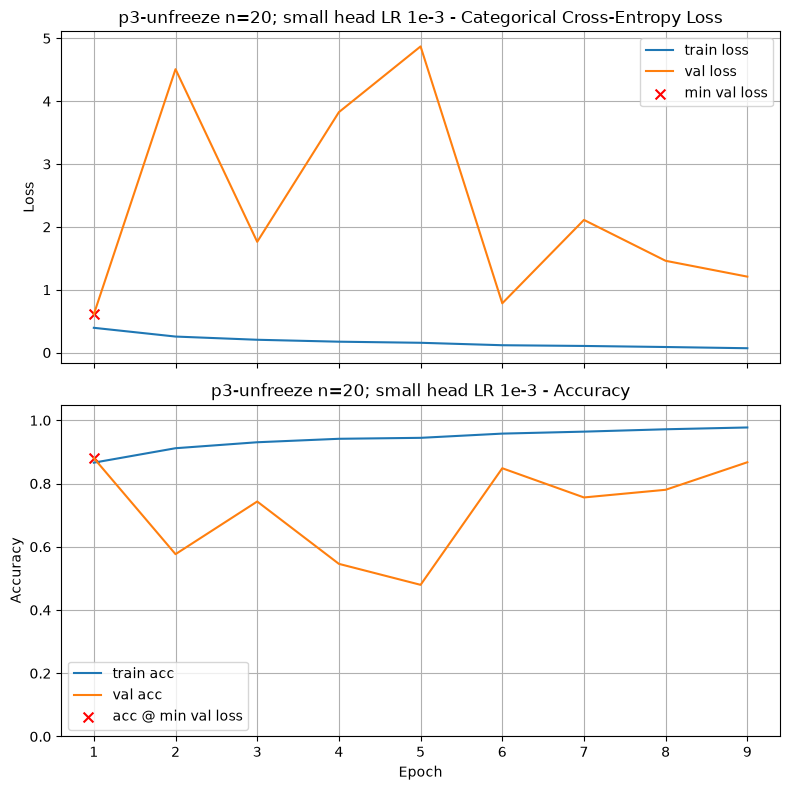

Final Training Loss:            0.0695
Final Training Accuracy:        0.9774
Final Validation Loss:          1.2085
Final Validation Accuracy:      0.8673
Minimum Validation Loss:        0.6101 (Epoch 1)
Validation Accuracy @ Min Loss: 0.8805

Test Loss: 0.6023
Test Accuracy: 0.8760

Validation-Test Gap (accuracy): 0.004528

Execution Time: 00:01:27

p3-unfreeze n=80;  small head LR 1e-3



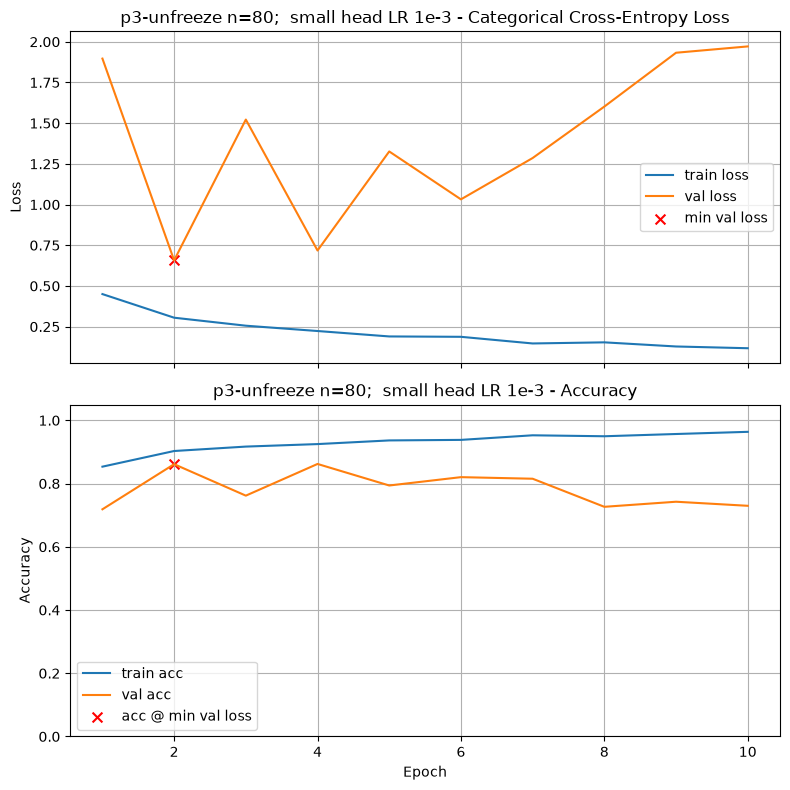

Final Training Loss:            0.1175
Final Training Accuracy:        0.9636
Final Validation Loss:          1.9714
Final Validation Accuracy:      0.7297
Minimum Validation Loss:        0.6572 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8613

Test Loss: 0.7580
Test Accuracy: 0.8540

Validation-Test Gap (accuracy): 0.007270

Execution Time: 00:02:13

p3-unfreeze n=80;  small head LR 1e-4



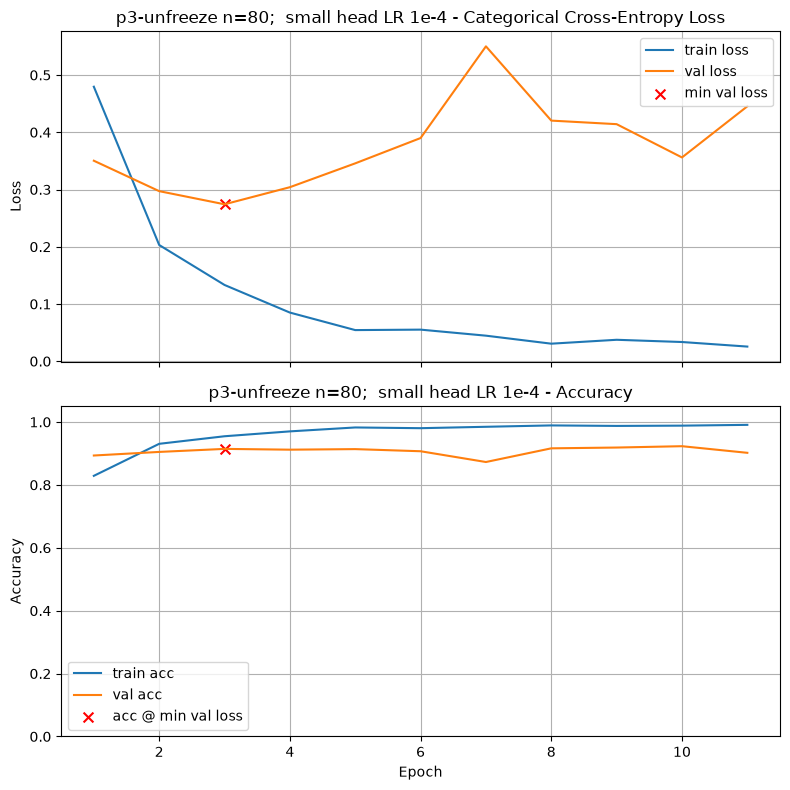

Final Training Loss:            0.0256
Final Training Accuracy:        0.9908
Final Validation Loss:          0.4453
Final Validation Accuracy:      0.9019
Minimum Validation Loss:        0.2742 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9144

Test Loss: 0.2375
Test Accuracy: 0.9150

Validation-Test Gap (accuracy): 0.000592

Execution Time: 00:02:21

p3-unfreeze n=80;  small head LR 1e-3, reduce, L2 1e-4


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


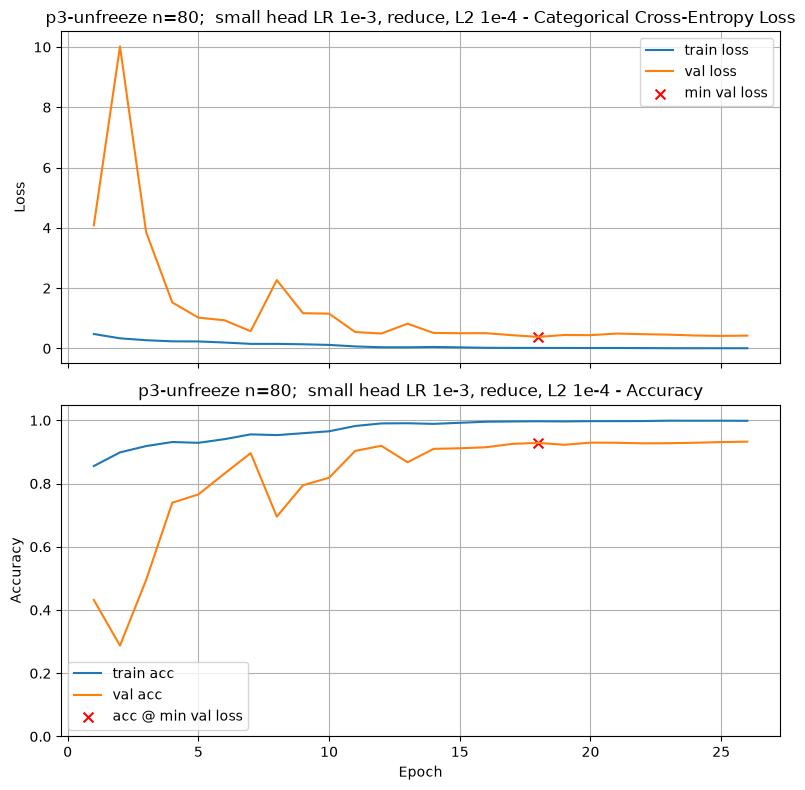

Final Training Loss:            0.0075
Final Training Accuracy:        0.9984
Final Validation Loss:          0.4259
Final Validation Accuracy:      0.9326
Minimum Validation Loss:        0.3833 (Epoch 18)
Validation Accuracy @ Min Loss: 0.9287

Test Loss: 0.3691
Test Accuracy: 0.9267

Validation-Test Gap (accuracy): 0.002007

Execution Time: 00:04:35


In [22]:
# Your code here; add as many cells as you need

def p3_unfreeze_some(
        basemodel, 
        n
):
    basemodel.trainable = True 

    for l in basemodel.layers[:-n]:
        l.trainable = False


#### ----------------------------------------------------- ####


p3_head_configs = {
    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
}



p3_experiments = {
    "p3-unfreeze n=20; small head LR 1e-3":    dict(
                                        head="small",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        unfreeze_n = 20,
                                        l2_reg=None),

    "p3-unfreeze n=80;  small head LR 1e-3":    dict(
                                            head="small",  
                                            lr=1e-3, 
                                            earlystop = True,
                                            reduceLR = False,
                                            unfreeze_n = 80,
                                            l2_reg=None),

    "p3-unfreeze n=80;  small head LR 1e-4":    dict(
                                                head="small",  
                                                lr=1e-4, 
                                                earlystop = True,
                                                reduceLR = False,
                                                unfreeze_n = 80,
                                                l2_reg=None),

     "p3-unfreeze n=80;  small head LR 1e-3, reduce, L2 1e-4":    dict(
                                                 head="small",  
                                                 lr=1e-3, 
                                                 earlystop = True,
                                                 reduceLR = [reduce_lr],
                                                 unfreeze_n = 80,
                                                 l2_reg=1e-4),                               



}

for title, config in p3_experiments.items():
    tf.keras.backend.clear_session()

    basemodel = make_base_model_pooled()

    p3_model = p1_buildmodel(
        backbone=basemodel,
        head_config=p3_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
    )

    p3_unfreeze_some(basemodel, config["unfreeze_n"])

    train_and_test(
        p3_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = False
    )


    del basemodel
    del p3_model




### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which partial-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(N\) layers of MobileNetV2?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(N\) of unfrozen layers**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about how much of a pretrained backbone should be unfrozen during fine-tuning.



**Your paragraph here (5pts):**

> Answer. 
When unfreezing some of the last layers, the chart shows oscillating validation loss, which showing possible overfitting issues. It is possible because of the data fraction is too small for now. Seems that the lower learning rate helps in reducing the overfitting issue for now. For now, the accuracy of larger layers (n=80) is greater than smaller layers (n=20). 

**Validation accuracy here (15 pts):**

In [23]:
results

{'Model Baseline': (0.901925802230835, 3),
 'p1- small head - base LR 1e-3': (0.909771740436554, 5),
 'p1- larger head - base LR 1e-3': (0.9037089943885803, 3),
 'p1- small do head - base LR 1e-3': (0.9040656089782715, 2),
 'p1- larger head - lr 1e-4, reduce LR, l2 reg': (0.9072753190994263, 12),
 'p2- small head - base LR 1e-3': (0.6269614696502686, 1),
 'p2- larger head - base LR 1e-3': (0.7389443516731262, 2),
 'p2- small head - LR 1e-5': (0.9133380651473999, 10),
 'p2- small head - lr 1e-5, reduce LR, l2 reg': (0.9222539067268372, 12),
 'p3-unfreeze n=20; small head LR 1e-3': (0.8805277943611145, 1),
 'p3-unfreeze n=80;  small head LR 1e-3': (0.8612695932388306, 2),
 'p3-unfreeze n=80;  small head LR 1e-4': (0.9144079685211182, 3),
 'p3-unfreeze n=80;  small head LR 1e-3, reduce, L2 1e-4': (0.9286733269691467,
  18)}

In [35]:
# Set a3 to the validation accuracy found by your best model for this problem. 

a3 = 0.92867             # Replace 0.0 with your answer

In [36]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3 = {a3:.4f}') 

a3 = 0.9287


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** rather than the last $N$ individual layers, as in Problem 3. This provides a more meaningful way to control how much of the pretrained backbone is allowed to adapt.

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a **1280-D feature vector**. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the top $K$ stages using the following approach:

```python
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_model = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )
```

For example:

* $K=1$ unfreezes only `Conv_1`.
* $K=2$ unfreezes `block_16` and `Conv_1`.
* $K=3$ unfreezes `block_15`, `block_16`, and `Conv_1`.

### To Do

1. **Design at least three experiments** in which the **last $K$ stages are unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$
     *(Here, $K$ counts stages/blocks, not individual Keras layers.)*
   * **BatchNormalization strategy:** keep BN frozen vs. allow BN layers in the selected blocks to be trainable.
   * **Head architecture** (select one from Problem 1).
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether making BatchNormalization layers trainable helps or destabilizes training,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations, rather than to identify a single globally optimal setting.

3. **Select one configuration** (choice of $K$, BatchNormalization strategy, and training strategy), set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"`, so **do not** add another `GlobalAveragePooling2D()` layer.
* Unfreezing more blocks generally makes training **more sensitive to the learning rate** and may increase instability; this is part of what you are investigating.
* Learning rates around $1\times10^{-5}$ to $3\times10^{-5}$ are reasonable starting points for block-level fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/tmp/ipykernel_27223/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



p4-unfreeze Conv_1; base



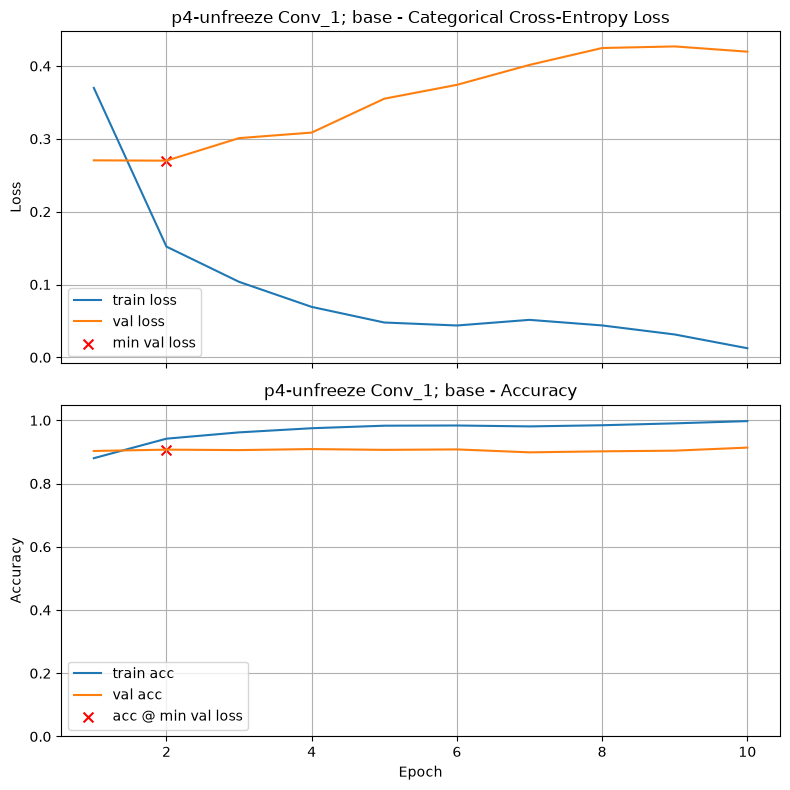

Final Training Loss:            0.0125
Final Training Accuracy:        0.9975
Final Validation Loss:          0.4197
Final Validation Accuracy:      0.9137
Minimum Validation Loss:        0.2700 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9073

Test Loss: 0.2575
Test Accuracy: 0.9160

Validation-Test Gap (accuracy): 0.008725

Execution Time: 00:01:19

p4-unfreeze k=2; base



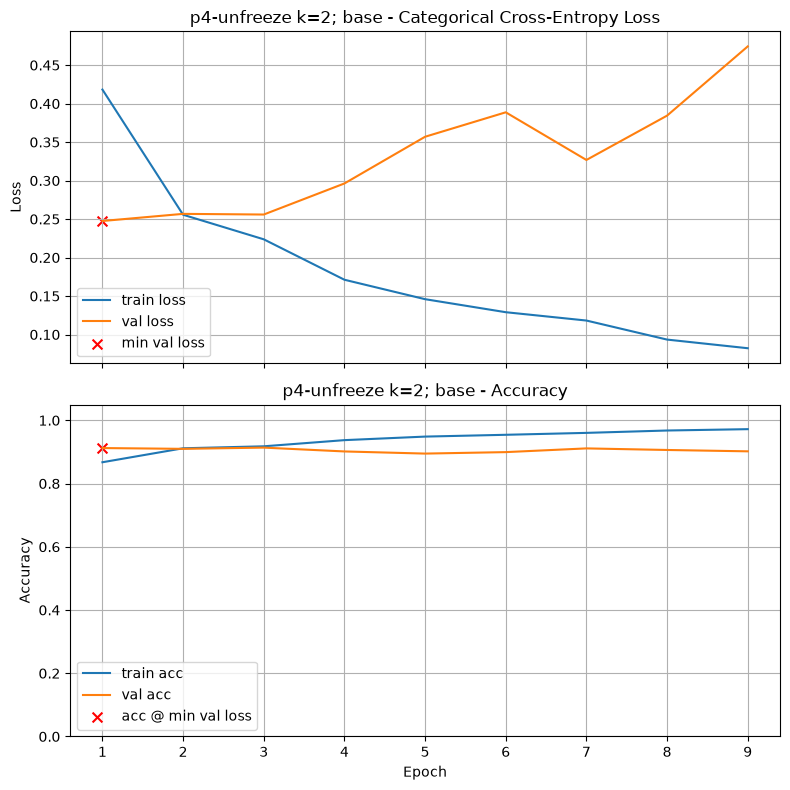

Final Training Loss:            0.0822
Final Training Accuracy:        0.9720
Final Validation Loss:          0.4743
Final Validation Accuracy:      0.9019
Minimum Validation Loss:        0.2475 (Epoch 1)
Validation Accuracy @ Min Loss: 0.9123

Test Loss: 0.2498
Test Accuracy: 0.9097

Validation-Test Gap (accuracy): 0.002602

Execution Time: 00:01:15

p4-unfreeze k=3; base



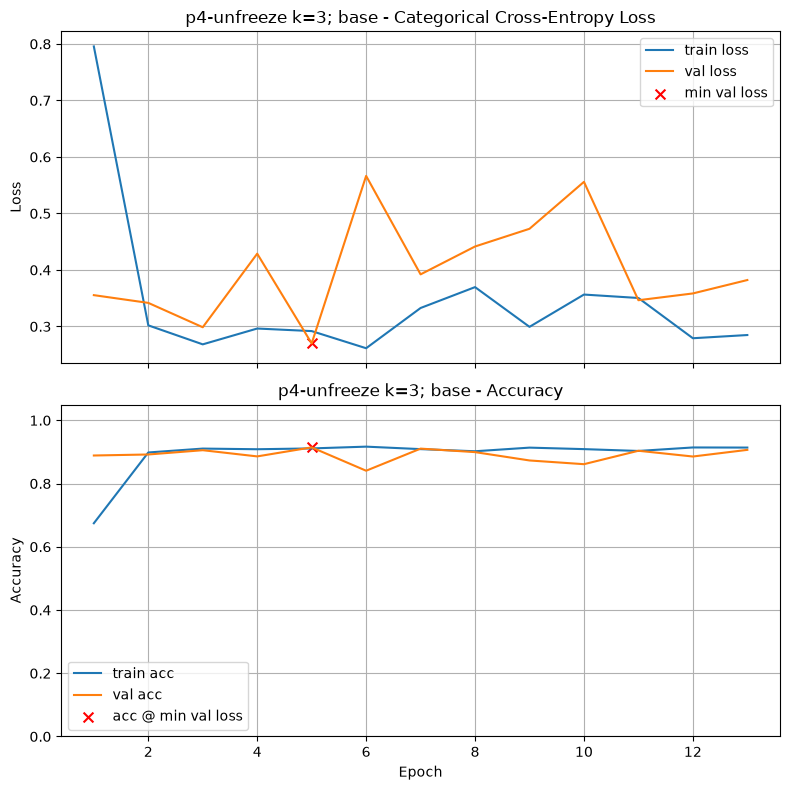

Final Training Loss:            0.2849
Final Training Accuracy:        0.9138
Final Validation Loss:          0.3822
Final Validation Accuracy:      0.9066
Minimum Validation Loss:        0.2701 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9144

Test Loss: 0.2621
Test Accuracy: 0.9173

Validation-Test Gap (accuracy): 0.002925

Execution Time: 00:01:46

p4-unfreeze k=2; small head



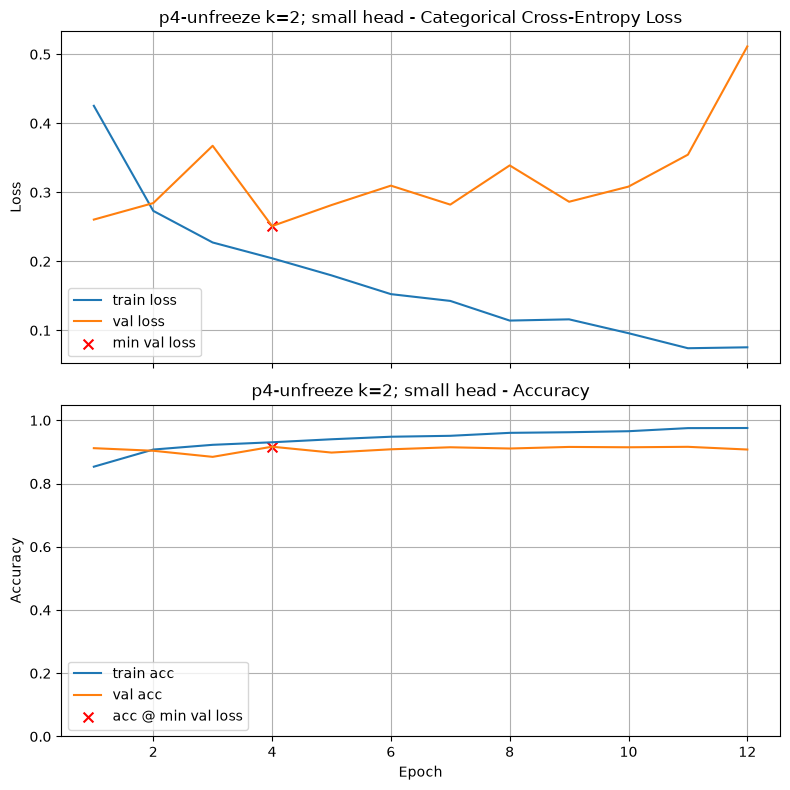

Final Training Loss:            0.0755
Final Training Accuracy:        0.9757
Final Validation Loss:          0.5114
Final Validation Accuracy:      0.9076
Minimum Validation Loss:        0.2511 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9165

Test Loss: 0.2335
Test Accuracy: 0.9173

Validation-Test Gap (accuracy): 0.000786

Execution Time: 00:01:40

p4-unfreeze k=2; small head + BN



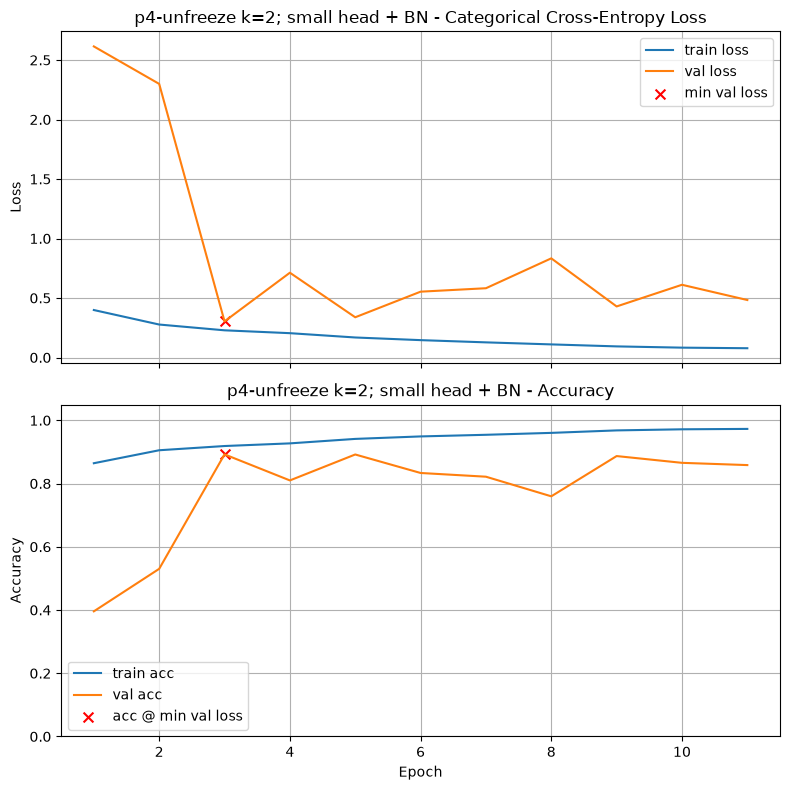

Final Training Loss:            0.0780
Final Training Accuracy:        0.9728
Final Validation Loss:          0.4831
Final Validation Accuracy:      0.8584
Minimum Validation Loss:        0.3035 (Epoch 3)
Validation Accuracy @ Min Loss: 0.8923

Test Loss: 0.2702
Test Accuracy: 0.9000

Validation-Test Gap (accuracy): 0.007703

Execution Time: 00:01:36

p4-unfreeze k=2; small head, lr 1e-4



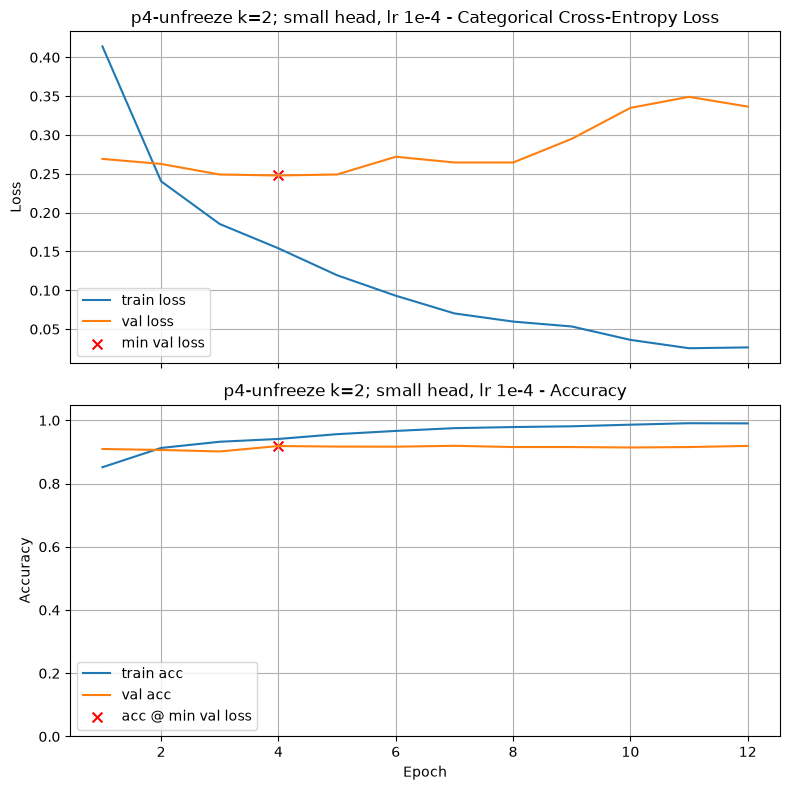

Final Training Loss:            0.0265
Final Training Accuracy:        0.9903
Final Validation Loss:          0.3366
Final Validation Accuracy:      0.9190
Minimum Validation Loss:        0.2478 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9187

Test Loss: 0.2351
Test Accuracy: 0.9173

Validation-Test Gap (accuracy): 0.001354

Execution Time: 00:01:38


In [26]:
# Your code here; add as many cells as you need

block_prefixes = [f"block_{i}" for i in range(1,17) ] + ["Conv_1"]

def belong_to_stage(layername, prefix):
    return layername == prefix or layername.startswith(prefix + "_")

def unfreeze_last_k_stages(base_model, k):
    ### notif
    if not 0 <= k <= len(block_prefixes):
        raise ValueError(f"k count")

                
           ##### •••••• ####

    selectedlayer = block_prefixes[-k:] if k > 0 else [] 

    base_model.trainable = True 

    for l in base_model.layers:
        if isinstance(l, tf.keras.layers.BatchNormalization):
            l.trainable = False
        else:
            l.trainable = any(belong_to_stage(l.name, p) for p in selectedlayer)

    ##------------
    trainable_names = [s.name for s in base_model.layers if s.trainable]

    return selectedlayer, trainable_names   


def p4_buildmodel(
        backbone,
        head_config, 
        l2_reg = None, 
        use_BN = False
):

    # backbone.trainable = False 
    
    model = models.Sequential([
        tf.keras.layers.Input(shape=INPUT_SHAPE),
        backbone
        ])

    l2reg = tf.keras.regularizers.L2(l2_reg) if l2_reg else None

    for layer_cfg in head_config:
        if layer_cfg["type"] == "dense":
            model.add(tf.keras.layers.Dense(
                units=layer_cfg["units"],
                activation=None,
                use_bias = not use_BN,
                kernel_regularizer=l2reg
            ))

            if use_BN:
                model.add(tf.keras.layers.BatchNormalization())

            model.add(tf.keras.layers.Activation("relu"))


        elif layer_cfg["type"] == "dropout":
            model.add(tf.keras.layers.Dropout(
                rate=layer_cfg["rate"]
            ))


    model.add(tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    ))

    return model



p4_head_configs = {
    "none" : [],

    "small": [
        {"type": "dense",   "units": 128},
        {"type": "dropout", "rate": 0.3},
    ],
}



p4_experiments = {
    ## --- base
    "p4-unfreeze Conv_1; base":    dict(
                                        head="none",  
                                        lr=1e-3, 
                                        earlystop = True,
                                        reduceLR = False,
                                        k_layer = 1,
                                        batch_norm_layer = False,
                                        l2_reg=None),

    "p4-unfreeze k=2; base":    dict(
                                            head="none",  
                                            lr=1e-3, 
                                            earlystop = True,
                                            reduceLR = False,
                                            k_layer = 2,
                                            batch_norm_layer = False,
                                            l2_reg=None),

    "p4-unfreeze k=3; base":    dict(
                                            head="none",  
                                            lr=1e-3, 
                                            earlystop = True,
                                            reduceLR = False,
                                            k_layer = 3,
                                            batch_norm_layer = False,
                                            l2_reg=None),    
## ------ change head
    "p4-unfreeze k=2; small head":    dict(
                                                head="small",  
                                                lr=1e-3, 
                                                earlystop = True,
                                                reduceLR = False,
                                                k_layer = 2,
                                                batch_norm_layer = False,
                                                l2_reg=None),

    "p4-unfreeze k=2; small head + BN":    dict(
                                                head="small",  
                                                lr=1e-3, 
                                                earlystop = True,
                                                reduceLR = False,
                                                k_layer = 2,
                                                batch_norm_layer = True,
                                                l2_reg=None),

    "p4-unfreeze k=2; small head, lr 1e-4":    dict(
                                                head="small",  
                                                lr=1e-4, 
                                                earlystop = True,
                                                reduceLR = False,
                                                k_layer = 2,
                                                batch_norm_layer = False,
                                                l2_reg=None),                                                                                                                                                                    

                              



}

for title, config in p4_experiments.items():
    tf.keras.backend.clear_session()

    basemodel = make_base_model_pooled(trainable= False)

    p4_model = p4_buildmodel(
        backbone=basemodel,
        head_config=p4_head_configs[config["head"]],
        l2_reg=config["l2_reg"],
        use_BN=config["batch_norm_layer"]
    )

    unfreeze_last_k_stages(basemodel, config["k_layer"])

    train_and_test(
        p4_model,
        lr_schedule = config["lr"],
        optimizer = "Adam",
        title = title, 
        use_early_stopping = config["earlystop"],
        callbacks = config["reduceLR"],
        verbose = 0,
        return_history = False
    )


    del basemodel
    del p4_model



### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which block-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(K\) MobileNetV2 blocks?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(K\) of unfrozen blocks**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* If you experimented with BatchNormalization, comment briefly on whether keeping BN frozen or allowing it to train appeared to help or destabilize training.
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about selecting how many pretrained blocks to unfreeze during fine-tuning.



**Your paragraph here (5pts):**

> Answer.
From the result of testing the base model, but different layers, I found that k=2 (Conv_1 and block_16) configuration had the highest accuracy. The result of this accuracy is the highest too among the base models from above. 

**Validation accuracy (15pts):**

In [27]:
results

{'Model Baseline': (0.901925802230835, 3),
 'p1- small head - base LR 1e-3': (0.909771740436554, 5),
 'p1- larger head - base LR 1e-3': (0.9037089943885803, 3),
 'p1- small do head - base LR 1e-3': (0.9040656089782715, 2),
 'p1- larger head - lr 1e-4, reduce LR, l2 reg': (0.9072753190994263, 12),
 'p2- small head - base LR 1e-3': (0.6269614696502686, 1),
 'p2- larger head - base LR 1e-3': (0.7389443516731262, 2),
 'p2- small head - LR 1e-5': (0.9133380651473999, 10),
 'p2- small head - lr 1e-5, reduce LR, l2 reg': (0.9222539067268372, 12),
 'p3-unfreeze n=20; small head LR 1e-3': (0.8805277943611145, 1),
 'p3-unfreeze n=80;  small head LR 1e-3': (0.8612695932388306, 2),
 'p3-unfreeze n=80;  small head LR 1e-4': (0.9144079685211182, 3),
 'p3-unfreeze n=80;  small head LR 1e-3, reduce, L2 1e-4': (0.9286733269691467,
  18),
 'p4-unfreeze Conv_1; base': (0.9072753190994263, 2),
 'p4-unfreeze k=2; base': (0.9122681617736816, 1),
 'p4-unfreeze k=3; base': (0.9144079685211182, 5),
 'p4-unfree

In [33]:
# Set a4 to the validation accuracy found by your best model for this problem. 

a4 = 0.9186875            # Replace 0.0 with your answer

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4 = {a4:.4f}') 

a4 = 0.9187


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework. 

This reflection question is worth 5 points. 

In [ ]:
finalrun = time.time()

totalrun = format_hms(finalrun - allrun)



In [ ]:
print(totalrun)  ##___45 min

00:45:35


In [31]:
# Print out summary of validation accuracy for each experiment

print_results()

p3-unfreeze n=80;  small head LR 1e-3, reduce, L2 1e-4	0.9287	18
p2- small head - lr 1e-5, reduce LR, l2 reg	0.9223	12
p4-unfreeze k=2; small head, lr 1e-4    	0.9187	4
p4-unfreeze k=2; small head             	0.9165	4
p3-unfreeze n=80;  small head LR 1e-4   	0.9144	3
p4-unfreeze k=3; base                   	0.9144	5
p2- small head - LR 1e-5                	0.9133	10
p4-unfreeze k=2; base                   	0.9123	1
p1- small head - base LR 1e-3           	0.9098	5
p1- larger head - lr 1e-4, reduce LR, l2 reg	0.9073	12
p4-unfreeze Conv_1; base                	0.9073	2
p1- small do head - base LR 1e-3        	0.9041	2
p1- larger head - base LR 1e-3          	0.9037	3
Model Baseline                          	0.9019	3
p4-unfreeze k=2; small head + BN        	0.8923	3
p3-unfreeze n=20; small head LR 1e-3    	0.8805	1
p3-unfreeze n=80;  small head LR 1e-3   	0.8613	2
p2- larger head - base LR 1e-3          	0.7389	2
p2- small head - base LR 1e-3           	0.6270	1


### Graded Question

### Final Reflection

Looking across the validation accuracies from your **full-dataset runs**, what patterns or lessons stand out from the different transfer-learning strategies you explored?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Compare the overall results from the frozen backbone, fully trainable backbone, partial layer unfreezing, and block-level unfreezing experiments.
* Highlight at least one design choice or training hyperparameter that appeared especially important.
* Mention any result that surprised you or differed from what you expected, if applicable.
* Conclude with a brief takeaway about what you learned about transfer learning from the homework.



**Your paragraph here (5pts):**

> Answer.
From the results of changing multiple parts of the mobilenet model, it seems the highest results come from the unfreezing the convolutional layers. But the simplest change is just by adding a proper head design. Even with simple one layer head and one dropout layer, the accuracy had increased in a good amount.
It seems that when keeping the backbone frozen, hyperparameters did not help to improve the accuracy significantly.
But when the backbone was unfrozen and some layers are trainable, hyperparameters could help improving the accuracy. 

## Appendix: What is MobileNetV2 (in plain English)?

`MobileNetV2` is a lightweight convolutional neural network (CNN) designed for efficient inference on resource-constrained devices while maintaining strong image-classification accuracy.

It achieves this with two important ideas:

1. **Depthwise-separable convolutions**

   Instead of using one expensive 3×3 convolution that mixes spatial information and channels at the same time, MobileNetV2 separates the operation into two steps:

   * a **depthwise 3×3 convolution**, which applies one spatial filter to each input channel separately, followed by
   * a **pointwise 1×1 convolution**, which mixes information across channels.

   This greatly reduces the number of parameters and computations compared with a standard convolution. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**

   A typical MobileNetV2 block has the following structure:

   * **Expand (1×1 convolution):** increase the number of channels, often by a factor of about 6, and apply a nonlinear activation.
   * **Depthwise (3×3 convolution):** process each channel separately and apply a nonlinear activation.
   * **Project (1×1 convolution):** reduce the number of channels again, but **without** applying a nonlinear activation. This is the **linear bottleneck**.

   If the input and output shapes match and the stride is 1, the block also adds a **skip connection**.

   The term **inverted residual** refers to the fact that the representation becomes wide inside the block and narrow again at the output, rather than the other way around.

   The final linear projection helps preserve information when the representation is compressed back to a lower-dimensional space. ([arXiv][1])

---

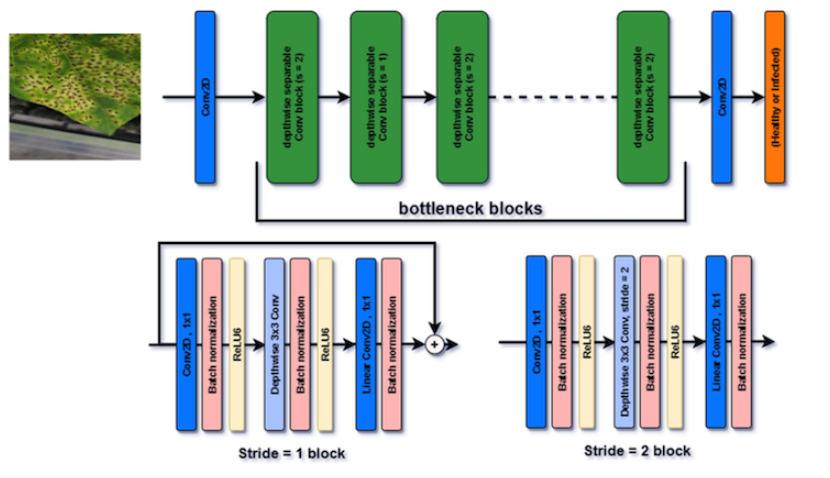

---

### What was MobileNetV2 trained on?

The Keras ImageNet weights for MobileNetV2 were trained on **ImageNet-1K**, a standard image-classification dataset containing:

* **1,281,167** training images
* **50,000** validation images
* **100,000** test images
* **1000 classes**

A common input size for MobileNetV2 is **224×224**. ([ImageNet][2])

For this homework, we use smaller **150×150** images to reduce training time.

Because we use:

```python
include_top=False
```

the pretrained convolutional backbone can operate on image sizes other than 224×224.

---

### Preprocessing

The preprocessing used for a pretrained network should match the preprocessing used when that network was originally trained.

For MobileNetV2, Keras provides:

```python
mobilenet_v2.preprocess_input
```

This function takes pixel values in their original approximately **0–255** range and scales them to approximately **[-1, 1]**.

In this homework, the image-loading pipeline applies this preprocessing before passing images to MobileNetV2. ([keras.io][3])

---

### How Keras exposes MobileNetV2

The following Keras call:

```python
tf.keras.applications.mobilenet_v2.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

returns a pretrained MobileNetV2 backbone with the original ImageNet classification head removed.

With:

```python
pooling="avg"
```

Keras applies **Global Average Pooling** to the final convolutional feature map. The result is a **1280-dimensional feature vector** for each image.

To use this backbone as a **frozen feature extractor**, we additionally set:

```python
base_model.trainable = False
```

The classification head that we add afterward can then be trained while the pretrained MobileNetV2 weights remain unchanged.

---

### What happens if `pooling="avg"` is omitted?

Without pooling, the backbone produces a spatial feature map rather than a single feature vector.

For a 224×224 input image, this feature map is typically:

```text
7 × 7 × 1280
```

Before connecting this to Dense layers, we would normally reduce the spatial dimensions using:

```python
GlobalAveragePooling2D()
```

which produces a 1280-dimensional vector.

`GlobalMaxPooling2D()` is another possible choice.

Using:

```python
Flatten()
```

is usually less attractive here because it would convert:

```text
7 × 7 × 1280
```

into:

```text
62,720
```

features, creating a much larger classification head.

In this homework, however, we use:

```python
pooling="avg"
```

inside MobileNetV2 itself, so **do not add another `GlobalAveragePooling2D()` layer**.

---

### How we use MobileNetV2 in this homework

We will experiment with several ways of using the pretrained backbone:

* **Frozen feature extraction:** keep all MobileNetV2 layers frozen and train only a new classification head.
* **Fully trainable backbone:** allow all MobileNetV2 layers to be updated during training.
* **Partial unfreezing:** keep most of the backbone frozen while allowing only selected upper layers or blocks to be updated.

These experiments let us investigate how much of the pretrained representation should be preserved and how much should be adapted to the Intel Image Classification dataset.

---

### TL;DR Summary

* Think of a MobileNetV2 block as:

  **expand → depthwise convolution → project (+ optional skip connection)**

* MobileNetV2 was pretrained to distinguish **1000 ImageNet classes**.

* In this homework, we reuse those learned visual features and train the model for our **6 Intel image classes**.

* With:

  ```python
  include_top=False,
  pooling="avg"
  ```

  the backbone outputs a **1280-D feature vector**.

* To use the backbone as a frozen feature extractor, set:

  ```python
  base_model.trainable = False
  ```

* Always match preprocessing to the pretrained backbone. For MobileNetV2, use:

  ```python
  mobilenet_v2.preprocess_input
  ```

  which scales the original pixel values to approximately **[-1, 1]**. ([keras.io][3])

---

### See also

* [https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/](https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/)

[1]: https://arxiv.org/abs/1801.04381
[2]: https://www.image-net.org/
[3]: https://keras.io/api/applications/mobilenet/mobilenet_models/


